Create Model 1 using Tensorflow

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import PIL

from tensorflow import keras
from tensorflow.keras import layers

datasetPath = kagglehub.dataset_download("ongshujian/real-and-fake-pokemon-cards")

def build_tensor_model(hp):
    base_filters = hp.Choice("base_filter", [16, 32]) # for feature extraction
    dense_units = hp.Choice("dense_units", [64, 128]) # for feature classification 
    activeFunctions = hp.Choice("activation", ["relu", "sigmoid", "tanh", "elu"]) # activation function.
    model = keras.models.Sequential([
        layers.Conv2D(base_filters, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 2, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Conv2D(base_filters * 4, 3, padding='same', activation=activeFunctions),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation=activeFunctions),
        layers.Dense(2)
    ])
    model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    return model



100%|██████████| 11.0M/11.0M [00:00<00:00, 242MB/s]

Extracting files...


Process the data and split into training and validation sets. Use Tensorflows function to work.

Trial 16 Complete [00h 00m 12s]
val_accuracy: 0.7733333110809326

Best val_accuracy So Far: 0.9200000166893005
Total elapsed time: 00h 03m 04s
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 310ms/step - accuracy: 0.5503 - loss: 1.3524 - val_accuracy: 0.6667 - val_loss: 0.6291
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6711 - loss: 0.6266 - val_accuracy: 0.6667 - val_loss: 0.5683
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7617 - loss: 0.5274 - val_accuracy: 0.7067 - val_loss: 0.5837
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7517 - loss: 0.5276 - val_accuracy: 0.8400 - val_loss: 0.4562
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7785 - loss: 0.4524 - val_accuracy: 0.8400 - val_loss: 0.3842
Index(['base_filter', 'dense_units', 'activation', 'score'], dtype='object')
   base_filter  dense_units activation     score
0           16           64       relu  0.840000
1           16           64    sigmoid  0.666667
2 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,816,072 (148.07 MB)

 Trainable params: 12,938,690 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,877,382 (98.71 MB)

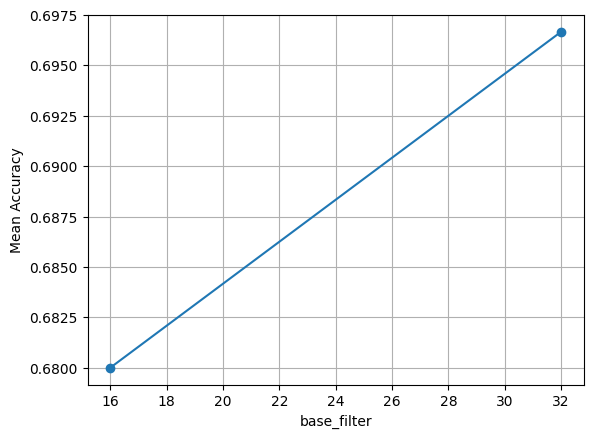

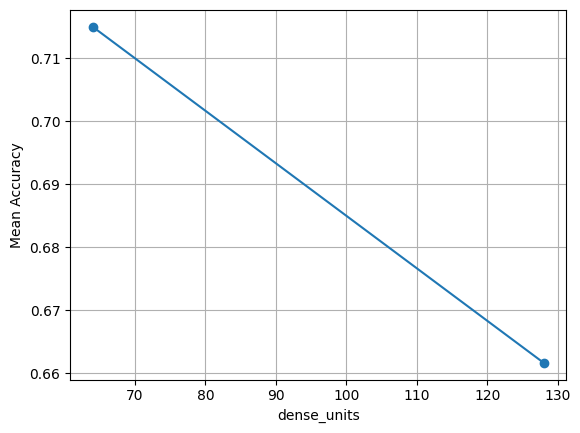

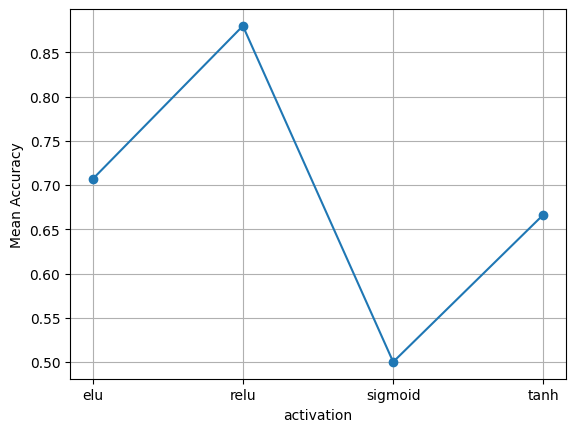

In [2]:
#install keras tuner so we can tune hypermodels in Tensorflow
%pip install -q -U keras-tuner

import os
#we'll use this tool for training validation split for relative ease of use
from sklearn.model_selection import train_test_split, GridSearchCV
import keras_tuner as kt

df = pd.read_csv(f"{datasetPath}/train_labels.csv") 
#shuffle dataset because the original dataset is ordered. We want to keep 
photoID_training, photoID_valid, classify_training, classify_valid = train_test_split(
    df["id"], df["label"],
    test_size= .2,
    stratify = df["label"],
    random_state=42
)


def processThroughImages(imagesCollection, labels, stage):
    imagesArray = []
    labelToReturn= []
    # Images 1 - 298 in our dataset will be our training data. Rest will be testing
    for imageID, label in zip(imagesCollection, labels):
        imageToProcessFilePath = os.path.join(datasetPath, stage, f"{imageID}.JPG")
        
        if not os.path.exists(imageToProcessFilePath):
            print(f"Missing: {imageToProcessFilePath}")
            continue

        imageToProcess = keras.utils.img_to_array(keras.utils.load_img(imageToProcessFilePath, target_size=[224,224]))
        
        imagesArray.append(imageToProcess)
        labelToReturn.append(label)
    
    
    return np.array(imagesArray), np.array(labelToReturn)

trainingImagesArray, trainingClassifyArray = processThroughImages(photoID_training, classify_training, "train")
validationImagesArray, validationClassifyArray = processThroughImages(photoID_valid, classify_valid, "train")

#normalize for model's ease
trainingImagesArray /= 255.0
validationImagesArray /= 255.0

# hypertune parameters with model 1 and see what we can do
model1Tuner = kt.GridSearch(
    build_tensor_model,
    objective="val_accuracy",
    max_trials=None,
    directory="fakeCardTensorflowLogs",
    project_name="pokemonFakeCardClassifier"
)

model1Tuner.search(
    trainingImagesArray, trainingClassifyArray,
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

# display our results of our tuning here. 
def showHyperPlot(param: str, results, groupBy="mean_test_score"):
  toPlot = results.groupby(param)[groupBy].mean()
  plt.figure()
  plt.plot(toPlot.index, toPlot.values, marker="o")
  plt.xlabel(param)
  plt.ylabel("Mean Accuracy")
  plt.grid(True)
  plt.show()




# rebuild with best hyperparameters and get our final tuned model
model1 = model1Tuner.hypermodel.build(model1Tuner.get_best_hyperparameters(1)[0])

model1.fit(
    trainingImagesArray, trainingClassifyArray, 
    epochs = 5,
    validation_data=(validationImagesArray, validationClassifyArray)
)

model1Results = pd.DataFrame([
    {**t.hyperparameters.values, "score": t.score} for t in model1Tuner.oracle.trials.values() if t.score is not None
])
print(model1Results.columns)
print(model1Results.head())


model1.summary()
showHyperPlot("base_filter", model1Results, "score")
showHyperPlot("dense_units", model1Results, "score")
showHyperPlot("activation", model1Results, "score")

Let's try creation a second model and see which one is more accurate. We're going to build a scikit learn shallow learning model.

In [ ]:
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report
# I have to flatten arrays because sklearn only allows 1D arrays
def flattenArrays(arr):
    return arr.reshape(len(arr), -1)

#Let's tune hyperparameters
#tune max_depth
param_grid = {
  #add params to test
  'max_depth': [None, *range(1, 25)],
  'max_features': [1, 2, 3, 4],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(tree.DecisionTreeClassifier(), param_grid=param_grid, scoring='accuracy')

grid_search.fit(flattenArrays(trainingImagesArray), trainingClassifyArray)
print(grid_search.best_params_)

model2 = grid_search.best_estimator_
validationCheck = model2.predict(flattenArrays(validationImagesArray))
print(accuracy_score(validationCheck, validationClassifyArray))
print(classification_report(validationClassifyArray, validationCheck, target_names=["Fake Cards", "Real Cards"]))

#create the plots. Add param because it's a scikit model 
showHyperPlot("param_max_depth", pd.DataFrame(grid_search.cv_results_))
showHyperPlot("param_max_features", pd.DataFrame(grid_search.cv_results_))

KeyboardInterrupt: 

Test it on the test data we have set, then compare the two models. Pick the best one from here and export as a backend api

In [ ]:
#prepare test set
testDF = pd.read_csv(f"{datasetPath}/test_labels.csv").sample(frac=1, random_state=42).reset_index(drop=True)
testImagesArray, testClassifyArray = processThroughImages(testDF["id"], testDF["label"], "test")
# test model 1
testCheck1 = np.argmax(model1.predict(testImagesArray), axis=1)
print(f"Model 1 accuracy: {accuracy_score(testClassifyArray, testCheck1)}")
print(classification_report(testClassifyArray, testCheck1, target_names=["Fake Cards", "Real Cards"]))
# test model 2
testCheck2 = model2.predict(flattenArrays(testImagesArray))
print(f"Model 2 accuracy: {accuracy_score(testClassifyArray, testCheck2)}")
print(classification_report(testClassifyArray, testCheck2, target_names=["Fake Cards", "Real Cards"]))





3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
Model 1 accuracy: 0.7948717948717948
              precision    recall  f1-score   support

  Fake Cards       0.75      0.64      0.69        28
  Real Cards       0.81      0.88      0.85        50

    accuracy                           0.79        78
   macro avg       0.78      0.76      0.77        78
weighted avg       0.79      0.79      0.79        78

0.358974358974359
              precision    recall  f1-score   support

  Fake Cards       0.36      1.00      0.53        28
  Real Cards       0.00      0.00      0.00        50

    accuracy                           0.36        78
   macro avg       0.18      0.50      0.26        78
weighted avg       0.13      0.36      0.19        78



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
